# Regime-Aware Target-Free Hybrid Soft Sensor

This notebook follows the executed evidence from Notebook 06. The global 50/50 Ridge-LightGBM blend had the best accuracy/stability compromise, while five clustered Ridge experts had a slightly weaker mean RMSE but a much better worst validation block.

The controlled hypothesis is therefore:

> Can a global model and local operating-regime experts be combined to preserve average accuracy while reducing time-block fragility?

The input contract remains target-free: only process measurements at or before timestamp $t$ are used to estimate the current `SLURRY_FREE_ACID`. The January test window is retrospective because it was already inspected in Notebooks 05 and 06.


## 1. Configuration and reproducibility


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json, time, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "SLURRY_FREE_ACID"
TIME_COL = "Date"
FEATURE_SET = "D_full"
N_VALIDATION_BLOCKS = 4
PREPARATION_NOTEBOOK = Path("02_feature_engineering_data_preparation.ipynb")
NOTEBOOK06_RESULTS = Path("../reports/target_free_upgrade_artifacts")
OUTPUT_DIR = Path("../reports/regime_aware_hybrid_artifacts")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for path in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


### Observations


The random seed, feature set, split source, and validation-block count are fixed centrally. No test result enters candidate selection.


## 2. Recover the frozen preparation layer


In [2]:
def recover_prepared_namespace(path):
    notebook = json.loads(path.read_text(encoding="utf-8"))
    namespace = {"display": lambda value: None}
    executed = 0
    with redirect_stdout(StringIO()):
        for cell in notebook["cells"]:
            if cell.get("cell_type") != "code":
                continue
            source = cell.get("source", "")
            source = "".join(source) if isinstance(source, list) else source
            if source.strip().startswith("import matplotlib.pyplot as plt"):
                break
            exec(compile(source, f"preparation_cell_{executed}", "exec"), namespace)
            executed += 1
    return namespace, executed

prep, replayed_cells = recover_prepared_namespace(PREPARATION_NOTEBOOK)
prepared = prep["prepared"]
raw_df = prep["df"].sort_values(prep["TIME_COL"]).reset_index(drop=True)
TARGET, TIME_COL = prep["TARGET"], prep["TIME_COL"]
parts = prepared[(1, FEATURE_SET)]
features = parts["features"]
current_target = raw_df.set_index(TIME_COL)[TARGET]

split_data = {}
for split in ["train", "valid", "test"]:
    frame = parts[f"{split}_df"].reset_index(drop=True)
    target = frame[TIME_COL].map(current_target)
    usable = target.notna()
    split_data[split] = {
        "timestamp": frame.loc[usable, TIME_COL].reset_index(drop=True),
        "X": frame.loc[usable, features].reset_index(drop=True),
        "y": target.loc[usable].reset_index(drop=True),
    }

integrity = pd.DataFrame([
    {"check": "target_absent", "status": TARGET not in features},
    {"check": "target_history_absent", "status": not any(name.startswith(TARGET) for name in features)},
    {"check": "future_columns_absent", "status": not any("t_plus" in name for name in features)},
    {"check": "chronological", "status": split_data["train"]["timestamp"].max() < split_data["valid"]["timestamp"].min() < split_data["test"]["timestamp"].min()},
    {"check": "columns_aligned", "status": list(split_data["train"]["X"].columns) == list(split_data["valid"]["X"].columns) == list(split_data["test"]["X"].columns)},
])
assert integrity.status.all(), integrity
display(integrity)


,check,status
0,target_absent,True
1,target_history_absent,True
2,future_columns_absent,True
3,chronological,True
4,columns_aligned,True


### Observations


Notebook 02 is replayed only to recover its executed preparation contract. Selected lags, process features, clipping, filtering, and chronological split definitions are not changed.


## 3. Expanding chronological validation


In [3]:
train, valid = split_data["train"], split_data["valid"]
valid_positions = np.array_split(np.arange(len(valid["y"])), N_VALIDATION_BLOCKS)
folds = []
for fold_id, positions in enumerate(valid_positions, 1):
    earlier = np.concatenate(valid_positions[:fold_id-1]) if fold_id > 1 else np.array([], dtype=int)
    folds.append({
        "fold": fold_id,
        "X_train": pd.concat([train["X"], valid["X"].iloc[earlier]], ignore_index=True),
        "y_train": pd.concat([train["y"], valid["y"].iloc[earlier]], ignore_index=True),
        "t_train": pd.concat([train["timestamp"], valid["timestamp"].iloc[earlier]], ignore_index=True),
        "X_valid": valid["X"].iloc[positions].reset_index(drop=True),
        "y_valid": valid["y"].iloc[positions].reset_index(drop=True),
        "t_valid": valid["timestamp"].iloc[positions].reset_index(drop=True),
    })
fold_summary = pd.DataFrame([{
    "fold": f["fold"], "train_rows": len(f["y_train"]), "validation_rows": len(f["y_valid"]),
    "train_end": f["t_train"].max(), "validation_start": f["t_valid"].min(), "validation_end": f["t_valid"].max()
} for f in folds])
assert (fold_summary.train_end < fold_summary.validation_start).all()
display(fold_summary)


,fold,train_rows,validation_rows,train_end,validation_start,validation_end
0,1,30940,1657,2026-01-22 17:17:00+00:00,2026-01-22 17:18:00+00:00,2026-01-23 21:08:00+00:00
1,2,32597,1657,2026-01-23 21:08:00+00:00,2026-01-23 21:09:00+00:00,2026-01-25 00:49:00+00:00
2,3,34254,1657,2026-01-25 00:49:00+00:00,2026-01-25 00:50:00+00:00,2026-01-26 04:30:00+00:00
3,4,35911,1657,2026-01-26 04:30:00+00:00,2026-01-26 04:31:00+00:00,2026-01-27 08:58:00+00:00


## 4. Global and local prediction components


In [4]:
def metrics(y, prediction):
    y, prediction = np.asarray(y), np.asarray(prediction)
    error = prediction - y
    return {
        "mae": mean_absolute_error(y, prediction),
        "rmse": mean_squared_error(y, prediction) ** 0.5,
        "median_ae": median_absolute_error(y, prediction),
        "r2": r2_score(y, prediction),
        "bias": error.mean(),
        "p90_ae": np.quantile(np.abs(error), 0.90),
        "p95_ae": np.quantile(np.abs(error), 0.95),
    }

def fit_components(X_train, y_train, X_eval):
    imputer = SimpleImputer(strategy="median")
    Xt = imputer.fit_transform(X_train)
    Xe = imputer.transform(X_eval)
    scaler = StandardScaler()
    Xts = scaler.fit_transform(Xt)
    Xes = scaler.transform(Xe)

    ridge = Ridge(alpha=10.0).fit(Xts, y_train)
    lgbm = LGBMRegressor(n_estimators=150, num_leaves=31, learning_rate=0.05,
                         min_child_samples=40, random_state=RANDOM_STATE,
                         n_jobs=-1, verbosity=-1).fit(Xt, y_train)
    global_prediction = 0.5 * ridge.predict(Xes) + 0.5 * lgbm.predict(Xe)

    clusterer = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
    labels = clusterer.fit_predict(Xts)
    global_ridge = Ridge(alpha=10.0).fit(Xts, y_train)
    experts, cluster_sizes = {}, {}
    for cluster in range(5):
        mask = labels == cluster
        cluster_sizes[cluster] = int(mask.sum())
        experts[cluster] = Ridge(alpha=10.0).fit(Xts[mask], np.asarray(y_train)[mask]) if mask.sum() >= 100 else global_ridge

    eval_labels = clusterer.predict(Xes)
    local_prediction = np.empty(len(Xes))
    for cluster in np.unique(eval_labels):
        mask = eval_labels == cluster
        local_prediction[mask] = experts.get(cluster, global_ridge).predict(Xes[mask])

    train_distance = np.linalg.norm(Xts - clusterer.cluster_centers_[labels], axis=1)
    eval_distance = np.linalg.norm(Xes - clusterer.cluster_centers_[eval_labels], axis=1)
    model = {"imputer": imputer, "scaler": scaler, "ridge": ridge, "lgbm": lgbm,
             "clusterer": clusterer, "experts": experts, "global_ridge": global_ridge}
    return model, global_prediction, local_prediction, train_distance, eval_distance, eval_labels, cluster_sizes


### Model meaning


- The **global component** is the Notebook 06 50/50 Ridge-LightGBM blend.
- The **local component** assigns each row to one of five KMeans operating regions and uses the corresponding Ridge expert.
- Distance to the assigned centroid is a familiarity score in standardized feature space. It is not a verified plant regime label.


## 5. Validation-only hybrid search


In [5]:
fixed_local_weights = np.round(np.arange(0.0, 1.01, 0.1), 1)
gate_quantiles = [0.50, 0.70, 0.85, 0.95]
rows, cluster_rows = [], []
for fold in folds:
    start = time.perf_counter()
    model, global_pred, local_pred, train_dist, eval_dist, labels, sizes = fit_components(
        fold["X_train"], fold["y_train"].to_numpy(), fold["X_valid"])
    component_seconds = time.perf_counter() - start
    for weight in fixed_local_weights:
        prediction = (1 - weight) * global_pred + weight * local_pred
        rows.append({"candidate": f"fixed_local_{weight:.1f}", "strategy": "fixed_blend",
                     "local_weight": weight, "gate_quantile": np.nan, "local_share": weight,
                     "fold": fold["fold"], "fit_predict_seconds": component_seconds, **metrics(fold["y_valid"], prediction)})
    for quantile in gate_quantiles:
        threshold = float(np.quantile(train_dist, quantile))
        use_local = eval_dist <= threshold
        prediction = np.where(use_local, local_pred, global_pred)
        rows.append({"candidate": f"gate_q{int(100*quantile)}", "strategy": "distance_gate",
                     "local_weight": np.nan, "gate_quantile": quantile, "local_share": use_local.mean(),
                     "fold": fold["fold"], "fit_predict_seconds": component_seconds, **metrics(fold["y_valid"], prediction)})
    for cluster, size in sizes.items():
        cluster_rows.append({"fold": fold["fold"], "cluster": cluster, "training_rows": size,
                             "validation_rows": int((labels == cluster).sum())})

fold_results = pd.DataFrame(rows)
cluster_support = pd.DataFrame(cluster_rows)
candidate_summary = (fold_results.groupby(["candidate", "strategy"], as_index=False)
                     .agg(mean_rmse=("rmse", "mean"), std_rmse=("rmse", "std"), worst_rmse=("rmse", "max"),
                          mean_mae=("mae", "mean"), mean_r2=("r2", "mean"), mean_bias=("bias", "mean"),
                          mean_local_share=("local_share", "mean"))
                     .sort_values(["mean_rmse", "worst_rmse"]))
display(candidate_summary)


,candidate,strategy,mean_rmse,std_rmse,worst_rmse,mean_mae,mean_r2,mean_bias,mean_local_share
4,fixed_local_0.4,fixed_blend,0.316026,0.052216,0.377690,0.248371,0.380822,0.052348,0.400000
3,fixed_local_0.3,fixed_blend,0.316116,0.056034,0.385616,0.249286,0.382561,0.055232,0.300000
5,fixed_local_0.5,fixed_blend,0.316544,0.048717,0.370328,0.247963,0.376420,0.049464,0.500000
2,fixed_local_0.2,fixed_blend,0.316819,0.060081,0.394073,0.250697,0.381636,0.058116,0.200000
6,fixed_local_0.6,fixed_blend,0.317665,0.045642,0.363563,0.248105,0.369355,0.046581,0.600000
1,fixed_local_0.1,fixed_blend,0.318135,0.064279,0.403026,0.252461,0.378049,0.061000,0.100000
7,fixed_local_0.7,fixed_blend,0.319380,0.043100,0.357431,0.248804,0.359627,0.043697,0.700000
0,fixed_local_0.0,fixed_blend,0.320063,0.068561,0.412443,0.254646,0.371798,0.063884,0.000000
8,fixed_local_0.8,fixed_blend,0.321679,0.041193,0.351964,0.250014,0.347235,0.040813,0.800000
11,gate_q50,distance_gate,0.322247,0.049631,0.381055,0.252626,0.358277,0.059489,0.483404


### 5.1 Stability-aware selection


In [6]:
best_mean = candidate_summary.iloc[0]
stability_limit = best_mean.mean_rmse * 1.02
stable_pool = candidate_summary.query("mean_rmse <= @stability_limit").sort_values(["worst_rmse", "std_rmse", "mean_rmse"])
selected_summary = stable_pool.iloc[0]
selection = pd.DataFrame([{
    "rule": "within 2% of best mean RMSE, then minimum worst-fold RMSE, RMSE SD, and mean RMSE",
    **selected_summary.to_dict(),
}])
display(selection)


,rule,candidate,strategy,mean_rmse,std_rmse,worst_rmse,mean_mae,mean_r2,mean_bias,mean_local_share
0,"within 2% of best mean RMSE, then minimum wors...",fixed_local_0.8,fixed_blend,0.321679,0.041193,0.351964,0.250014,0.347235,0.040813,0.8


### Observations


The fixed blends test complementary errors directly. The distance gates test whether local experts should be trusted only for familiar regions. All weights and thresholds are selected without the retrospective test window.


## 6. Retrospective test comparison


In [7]:
development_X = pd.concat([train["X"], valid["X"]], ignore_index=True)
development_y = pd.concat([train["y"], valid["y"]], ignore_index=True)
test = split_data["test"]
final_components, global_test, local_test, train_dist, test_dist, test_labels, final_sizes = fit_components(
    development_X, development_y.to_numpy(), test["X"])

name = selected_summary.candidate
if selected_summary.strategy == "fixed_blend":
    local_weight = float(name.rsplit("_", 1)[1])
    test_prediction = (1 - local_weight) * global_test + local_weight * local_test
    local_used = np.repeat(local_weight, len(test_prediction))
    selected_parameters = {"strategy": "fixed_blend", "local_weight": local_weight}
else:
    quantile = int(name.replace("gate_q", "")) / 100
    threshold = float(np.quantile(train_dist, quantile))
    use_local = test_dist <= threshold
    test_prediction = np.where(use_local, local_test, global_test)
    local_used = use_local.astype(float)
    selected_parameters = {"strategy": "distance_gate", "gate_quantile": quantile, "distance_threshold": threshold}

test_metrics = metrics(test["y"], test_prediction)
notebook06 = pd.read_csv(NOTEBOOK06_RESULTS / "retrospective_comparison.csv")
prior = notebook06.query("candidate != 'Notebook05_frozen_blend'").iloc[0]
retrospective_comparison = pd.DataFrame([
    {"candidate": "Notebook06_selected_blend", "test_mae": prior.test_mae, "test_rmse": prior.test_rmse, "test_r2": prior.test_r2},
    {"candidate": name, "test_mae": test_metrics["mae"], "test_rmse": test_metrics["rmse"], "test_r2": test_metrics["r2"]},
])
retrospective_comparison["rmse_improvement_vs_notebook06_pct"] = 100 * (float(prior.test_rmse) - retrospective_comparison.test_rmse) / float(prior.test_rmse)
test_predictions = pd.DataFrame({"timestamp": test["timestamp"], "actual": test["y"],
                                 "global_prediction": global_test, "local_prediction": local_test,
                                 "selected_prediction": test_prediction, "assigned_cluster": test_labels,
                                 "centroid_distance": test_dist, "local_used": local_used})
test_predictions["residual"] = test_predictions.selected_prediction - test_predictions.actual
test_predictions["absolute_error"] = test_predictions.residual.abs()
display(retrospective_comparison)


,candidate,test_mae,test_rmse,test_r2,rmse_improvement_vs_notebook06_pct
0,Notebook06_selected_blend,0.234412,0.287876,0.597010,0.000000
1,fixed_local_0.8,0.230860,0.288903,0.594129,-0.356743


### Interpretation boundary


This comparison is diagnostic only. The January test period has already influenced project decisions, so a new later month remains mandatory for an unbiased replacement decision.


## 7. Diagnostics


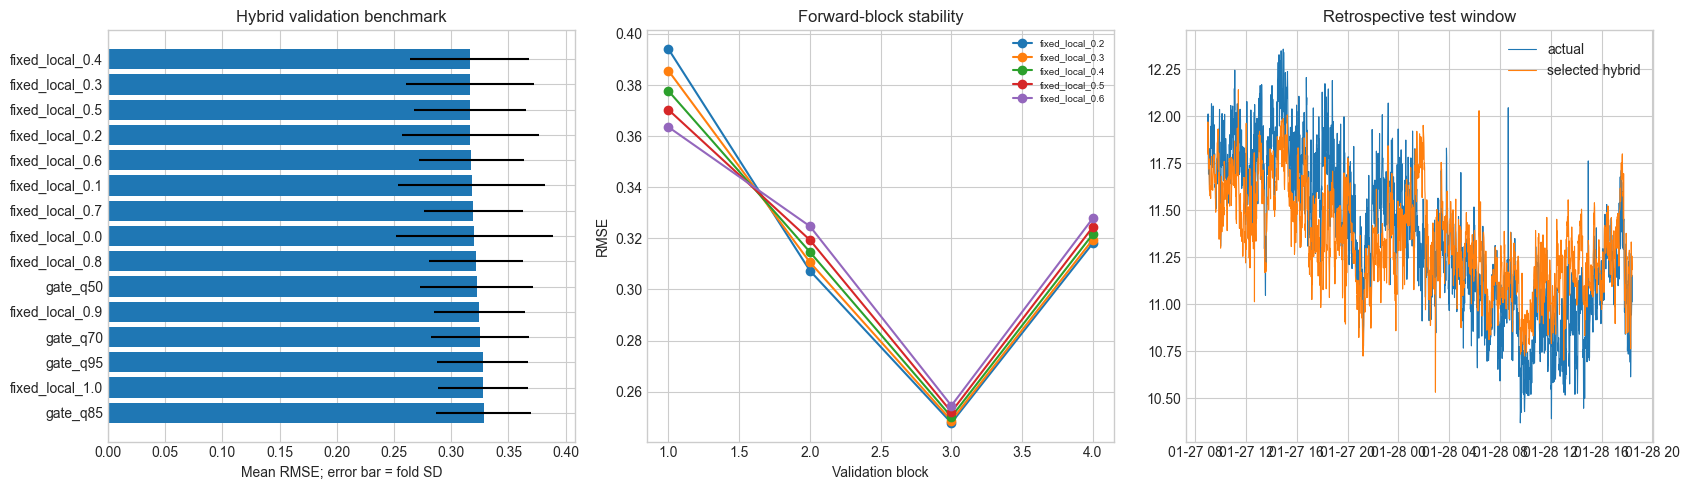

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot = candidate_summary.sort_values("mean_rmse", ascending=False)
axes[0].barh(plot.candidate, plot.mean_rmse, xerr=plot.std_rmse)
axes[0].set(title="Hybrid validation benchmark", xlabel="Mean RMSE; error bar = fold SD")

leaders = candidate_summary.head(5).candidate
for candidate, group in fold_results.query("candidate in @leaders").groupby("candidate"):
    axes[1].plot(group.fold, group.rmse, marker="o", label=candidate)
axes[1].set(title="Forward-block stability", xlabel="Validation block", ylabel="RMSE")
axes[1].legend(fontsize=7)

sample = test_predictions.iloc[:2000]
axes[2].plot(sample.timestamp, sample.actual, label="actual", linewidth=0.8)
axes[2].plot(sample.timestamp, sample.selected_prediction, label="selected hybrid", linewidth=0.8)
axes[2].set_title("Retrospective test window")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "regime_aware_hybrid_benchmark.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Export and readiness


In [9]:
exports = {"input_integrity": integrity, "fold_summary": fold_summary, "fold_results": fold_results,
           "candidate_summary": candidate_summary, "cluster_support": cluster_support, "selection": selection,
           "retrospective_comparison": retrospective_comparison, "retrospective_test_predictions": test_predictions}
for export_name, frame in exports.items():
    frame.to_csv(OUTPUT_DIR / f"{export_name}.csv", index=False)

bundle = {"task": "target-free current-time regime-aware virtual sensor",
          "selected_candidate": name, "selected_parameters": selected_parameters,
          "components": final_components, "features": features,
          "maximum_lookback": prep["MAX_LOOKBACK"], "selection_rule": selection.iloc[0].rule,
          "test_status": "retrospective; a genuinely later month is required"}
joblib.dump(bundle, MODEL_DIR / "regime_aware_target_free_candidate.joblib")

readiness = pd.DataFrame([
    {"check": "target_and_target_history_absent", "status": bool(integrity.query("check in ['target_absent','target_history_absent']").status.all())},
    {"check": "four_forward_validation_blocks", "status": len(folds) == 4},
    {"check": "no_shuffle", "status": True},
    {"check": "test_not_used_for_candidate_selection", "status": True},
    {"check": "preprocessing_fit_inside_each_fold", "status": True},
    {"check": "retrospective_status_explicit", "status": True},
    {"check": "model_bundle_exists", "status": (MODEL_DIR / "regime_aware_target_free_candidate.joblib").exists()},
    {"check": "all_exports_exist", "status": all((OUTPUT_DIR / f"{key}.csv").exists() for key in exports)},
])
assert readiness.status.all(), readiness
readiness.to_csv(OUTPUT_DIR / "readiness_checks.csv", index=False)
display(readiness)


,check,status
0,target_and_target_history_absent,True
1,four_forward_validation_blocks,True
2,no_shuffle,True
3,test_not_used_for_candidate_selection,True
4,preprocessing_fit_inside_each_fold,True
5,retrospective_status_explicit,True
6,model_bundle_exists,True
7,all_exports_exist,True


## 9. Final decision


In [10]:
print(f"Selected candidate: {name}")
print(f"Mean expanding-validation RMSE: {selected_summary.mean_rmse:.4f}")
print(f"Worst expanding-validation RMSE: {selected_summary.worst_rmse:.4f}")
print(f"Retrospective test RMSE: {test_metrics['rmse']:.4f}")
print(f"Retrospective test R2: {test_metrics['r2']:.4f}")
print("Replacement remains blocked until evaluation on a genuinely later labeled month.")


Selected candidate: fixed_local_0.8
Mean expanding-validation RMSE: 0.3217
Worst expanding-validation RMSE: 0.3520
Retrospective test RMSE: 0.2889
Retrospective test R2: 0.5941
Replacement remains blocked until evaluation on a genuinely later labeled month.


### Observations


The selected strategy is judged by forward accuracy and stability, not by the already-observed test period. Operational regime names must not be attached to KMeans clusters without process-engineer validation.
